# ***Questions 1-3: PiSSA Fine-Tuning***

## ***Setup***

### ***Environment***

In [1]:
import os

IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
LOCAL_GPU = '2,7'
if not IS_KAGGLE:
    os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
    os.environ['CUDA_VISIBLE_DEVICES'] = LOCAL_GPU

import gc
import json
import math
import os
import random
import re
import time
from dataclasses import dataclass
from fractions import Fraction
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import DatasetDict, load_dataset
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print('Python/PyTorch ready')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('GPU count:', torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

MIN_FREE_GPU_GB = 20.0
free_bytes, total_bytes = torch.cuda.mem_get_info(0)
print(f'Free GPU memory: {free_bytes / 1024**3:.1f} / {total_bytes / 1024**3:.1f} GB')
if not IS_KAGGLE and free_bytes / 1024**3 < MIN_FREE_GPU_GB:
    raise RuntimeError(
        f'GPU {LOCAL_GPU} has only {free_bytes / 1024**3:.1f} GB free; '
        f'pick a free GPU in LOCAL_GPU (need about {MIN_FREE_GPU_GB:.0f} GB).'
    )

Python/PyTorch ready
PyTorch: 2.5.1+cu121
CUDA available: True
GPU count: 2
0 NVIDIA GeForce RTX 3090
1 NVIDIA RTX A5000


Free GPU memory: 22.9 / 23.7 GB


### ***Configuration***

In [2]:
OUTPUT_DIR_NAME = 'outputs'


def find_output_root(*, start: Path) -> Path:
    for directory in (start, *start.parents):
        if (directory / OUTPUT_DIR_NAME).is_dir():
            return directory / OUTPUT_DIR_NAME
    return start / OUTPUT_DIR_NAME


RESULT_ROOT = (
    Path('/kaggle/working/Assignment1')
    if IS_KAGGLE
    else find_output_root(start=Path.cwd()) / f"{time.strftime('%Y-%m-%d')}_notebook_q1_q3"
)
RESULT_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_ID = 'meta-llama/Llama-3.2-1B'
MODEL_DTYPE = torch.float16
TRAIN_DEVICE = torch.device('cuda:0')
SVD_DEVICE = torch.device('cuda:0')

METAMATH_TRAIN_LIMIT = 25000
METAMATH_TRAIN_DATASET_ID = 'meta-math/MetaMathQA'

PISSA_EVAL_DATASET_ID = 'fxmeng/pissa-dataset'
PISSA_EVAL_DATA_DIR = 'metamath'
EVAL_TASKS = ['gsm8k', 'math']

MAX_LENGTH = 512
EPOCHS = 1
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.0
WARMUP_RATIO = 0.03
TARGET_GLOBAL_BATCH = 128

MICRO_BATCH_SIZE = 8
USE_DATA_PARALLEL = torch.cuda.device_count() >= 2
GRAD_ACCUM_STEPS = max(1, TARGET_GLOBAL_BATCH // MICRO_BATCH_SIZE)

EVAL_MAX_NEW_TOKENS = 256
EVAL_BATCH_SIZE = 4

SAVE_PREDICTIONS = True
SAVE_ADAPTERS = True
SAVE_FULL_MODEL = True


Q1_Q2_RUNS = [
    {'rank': 16, 'component': 'default'},
    {'rank': 64, 'component': 'default'},
    {'rank': 256, 'component': 'default'},
]
Q3_RUNS = [
    {'rank': 16, 'component': 'p25'},
    {'rank': 16, 'component': 'p50'},
    {'rank': 16, 'component': 'bottom'},
]
MANUAL_RUNS = Q1_Q2_RUNS + Q3_RUNS
RUN_FRESH_BASELINE = True

assert TARGET_GLOBAL_BATCH % MICRO_BATCH_SIZE == 0
print('Effective batch:', MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS)
print('MetaMathQA train limit:', METAMATH_TRAIN_LIMIT)
print('Evaluation tasks:', EVAL_TASKS)
print('Results:', RESULT_ROOT)

Effective batch: 128
MetaMathQA train limit: 25000
Evaluation tasks: ['gsm8k', 'math']
Results: /home/longpm/works/knowledge/big-data-nycu/hw1/outputs/2026-10-04_notebook_q1_q3


### ***Hugging Face Login***

In [3]:
from huggingface_hub import login

HF_TOKEN_NAME = 'HF_TOKEN'
ENV_FILE_NAME = '.env'


def read_kaggle_token(*, label: str) -> str | None:
    try:
        from kaggle_secrets import UserSecretsClient
    except ImportError:
        return None
    try:
        return UserSecretsClient().get_secret(label)
    except Exception:
        return None


def read_env_file_token(*, start: Path, name: str) -> str | None:
    from dotenv import dotenv_values

    for directory in (start, *start.parents):
        env_file = directory / ENV_FILE_NAME
        if env_file.is_file():
            return dotenv_values(env_file).get(name)
    return None


token = (
    os.environ.get(HF_TOKEN_NAME)
    or read_kaggle_token(label=HF_TOKEN_NAME)
    or read_env_file_token(
        start=Path.cwd(),
        name=HF_TOKEN_NAME,
    )
)
if token:
    login(token=token)
    print('Hugging Face login: OK')
else:
    print('HF_TOKEN not found; continuing with cached credentials if any.')

Hugging Face login: OK


### ***Tokenizer***

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.model_max_length = MAX_LENGTH

IGNORE_INDEX = -100
PISSA_PROMPT = (
    'Below is an instruction that describes a task. '
    'Write a response that appropriately completes the request.\n\n'
    '### Instruction:\n{instruction}\n\n### Response:'
)

print('Tokenizer:', MODEL_ID)
print('EOS:', tokenizer.eos_token_id, 'PAD:', tokenizer.pad_token_id)

Tokenizer: meta-llama/Llama-3.2-1B
EOS: 128001 PAD: 128001


## ***Data***

### ***Dataset Loaders***

In [5]:
def load_metamathqa_train_like_pissa():
    split = (
        'train'
        if METAMATH_TRAIN_LIMIT is None
        else f'train[:{METAMATH_TRAIN_LIMIT}]'
    )
    train = load_dataset(
        METAMATH_TRAIN_DATASET_ID,
        split=split,
    )

    train = train.map(
        lambda x: {
            'instruction': str(x['query']).strip(),
            'output': str(x['response']).strip(),
            'source_type': str(x.get('type', '')),
        },
        remove_columns=train.column_names,
        desc='Formatting MetaMathQA for PiSSA training',
    )
    return train


def load_pissa_metamath_eval():
    raw_test = load_dataset(
        PISSA_EVAL_DATASET_ID,
        data_dir=PISSA_EVAL_DATA_DIR,
        split='test',
    )

    eval_sets = {}
    normalized_types = [str(x).lower() for x in raw_test['type']]

    for task in EVAL_TASKS:
        keep_indices = [
            i for i, task_type in enumerate(normalized_types)
            if task_type == task
        ]
        subset = raw_test.select(keep_indices)
        if len(subset) == 0:
            raise RuntimeError(
                f'No {task!r} rows found in '
                f'{PISSA_EVAL_DATASET_ID}/{PISSA_EVAL_DATA_DIR} test split.'
            )

        subset = subset.map(
            lambda x: {
                'instruction': str(x['instruction']),
                'gold_answer': str(x['output']),
                'type': str(x['type']).lower(),
            },
            remove_columns=subset.column_names,
            desc=f'Formatting PiSSA {task} evaluation set',
        )
        eval_sets[task] = subset

    return eval_sets

### ***Dataset Loading***

In [6]:
TRAIN_DATASET = load_metamathqa_train_like_pissa()
EVAL_DATASETS = load_pissa_metamath_eval()

print('\nTRAIN:', TRAIN_DATASET)
print('train example:', TRAIN_DATASET[0])

for task, ds in EVAL_DATASETS.items():
    print(f'\nEVAL {task}:', ds)
    print('test example:', ds[0])


TRAIN: Dataset({
    features: ['instruction', 'output', 'source_type'],
    num_rows: 25000
})
train example: {'instruction': "Gracie and Joe are choosing numbers on the complex plane. Joe chooses the point $1+2i$. Gracie chooses $-1+i$. How far apart are Gracie and Joe's points?", 'output': "The distance between two points $(x_1,y_1)$ and $(x_2,y_2)$ in the complex plane is given by the formula $\\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}$.\nIn this case, Joe's point is $(1,2)$ and Gracie's point is $(-1,1)$.\nSo the distance between their points is $\\sqrt{((-1)-(1))^2+((1)-(2))^2}=\\sqrt{(-2)^2+(-1)^2}=\\sqrt{4+1}=\\sqrt{5}$.\nTherefore, Gracie and Joe's points are $\\boxed{\\sqrt{5}}$ units apart.\nThe answer is: \\sqrt{5}", 'source_type': 'MATH_AnsAug'}

EVAL gsm8k: Dataset({
    features: ['instruction', 'type', 'gold_answer'],
    num_rows: 1319
})
test example: {'instruction': "Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n##

### ***Tokenization***

In [7]:
def tokenize_supervised_example(example):
    source = PISSA_PROMPT.format(instruction=example['instruction'])
    target = f"{example['output']}\n{tokenizer.eos_token}"

    full = tokenizer(
        source + target,
        max_length=MAX_LENGTH,
        truncation=True,
        add_special_tokens=True,
    )
    source_tok = tokenizer(
        source,
        max_length=MAX_LENGTH,
        truncation=True,
        add_special_tokens=True,
    )

    input_ids = full['input_ids']
    labels = input_ids.copy()
    source_len = min(len(source_tok['input_ids']), len(labels))
    labels[:source_len] = [IGNORE_INDEX] * source_len

    return {
        'input_ids': input_ids,
        'labels': labels,
        'supervised_tokens': sum(v != IGNORE_INDEX for v in labels),
    }


@dataclass
class ResponseOnlyCollator:
    pad_token_id: int

    def __call__(self, features):
        max_len = max(len(x['input_ids']) for x in features)
        input_ids, labels, attention_mask = [], [], []

        for x in features:
            n_pad = max_len - len(x['input_ids'])
            input_ids.append(x['input_ids'] + [self.pad_token_id] * n_pad)
            labels.append(x['labels'] + [IGNORE_INDEX] * n_pad)
            attention_mask.append([1] * len(x['input_ids']) + [0] * n_pad)

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
        }


collator = ResponseOnlyCollator(tokenizer.pad_token_id)

TOKENIZED_TRAIN = TRAIN_DATASET.map(
    tokenize_supervised_example,
    remove_columns=TRAIN_DATASET.column_names,
    desc='Tokenizing MetaMathQA',
)
before = len(TOKENIZED_TRAIN)
TOKENIZED_TRAIN = TOKENIZED_TRAIN.filter(
    lambda x: x['supervised_tokens'] > 0,
    desc='Removing rows with no supervised tokens after truncation',
)
print('MetaMathQA train rows:', before, 'usable:', len(TOKENIZED_TRAIN))

MetaMathQA train rows: 25000 usable: 24975


## ***PiSSA Model***

### ***Model Loading***

In [8]:
def load_fresh_model(to_device=False):
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        dtype=MODEL_DTYPE,
        device_map='cpu',
        low_cpu_mem_usage=True,
    )
    model.config.use_cache = True
    if to_device:
        model = model.to(TRAIN_DEVICE)
    return model


def cleanup_model(model=None):
    if model is not None:
        try:
            model.to('cpu')
        except Exception:
            pass
        del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

### ***PiSSA Layer***

In [9]:
class PiSSALinear(nn.Module):
    def __init__(self, weight_residual, pissa_A, pissa_B, bias=None):
        super().__init__()
        out_features, in_features = weight_residual.shape
        rank = pissa_A.shape[1]
        assert pissa_A.shape == (out_features, rank)
        assert pissa_B.shape == (rank, in_features)

        self.rank = rank
        self.weight = nn.Parameter(weight_residual.contiguous(), requires_grad=False)
        self.pissa_A = nn.Parameter(pissa_A.float())
        self.pissa_B = nn.Parameter(pissa_B.float())
        if bias is None:
            self.register_parameter('bias', None)
        else:
            self.bias = nn.Parameter(bias.detach().clone(), requires_grad=False)

    def forward(self, x):
        frozen_out = F.linear(x, self.weight, self.bias)
        with torch.autocast(device_type=x.device.type, enabled=False):
            hidden = F.linear(x.float(), self.pissa_B)
            update = F.linear(hidden, self.pissa_A)
        return frozen_out + update.to(frozen_out.dtype)

### ***SVD Initialization***

In [10]:
@dataclass
class PiSSAInitStats:
    name: str
    rank: int
    component: str
    relative_error_stored: float

@torch.no_grad()
def pissa_from_linear_exact(linear, rank, component, layer_name=''):
    W = linear.weight.detach().to(SVD_DEVICE, dtype=torch.float32)
    out_features, in_features = W.shape
    k = min(out_features, in_features)
    if rank > k:
        raise ValueError(f'{layer_name}: rank={rank} > max rank={k}')

    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    component_starts = {
        'default': 0,
        'p25': len(S) // 4,
        'p50': len(S) // 2,
        'bottom': len(S) - rank,
    }
    if component not in component_starts:
        raise ValueError(component)
    start = component_starts[component]
    end = start + rank

    U_r, S_r, Vh_r = U[:, start:end], S[start:end], Vh[start:end, :]
    sqrt_S = torch.sqrt(S_r)
    A = U_r * sqrt_S.unsqueeze(0)
    B = sqrt_S.unsqueeze(1) * Vh_r
    W_res = W - (A @ B)

    stored = W_res.to(linear.weight.dtype).cpu()
    A_cpu, B_cpu, W_cpu = A.cpu(), B.cpu(), W.cpu()
    rel_err = (
        torch.linalg.vector_norm(W_cpu - (stored.float() + A_cpu @ B_cpu))
        / torch.linalg.vector_norm(W_cpu)
    ).item()

    replacement = PiSSALinear(
        stored,
        A_cpu,
        B_cpu,
        None if linear.bias is None else linear.bias.detach().cpu(),
    )
    stats = PiSSAInitStats(layer_name, rank, component, rel_err)

    del W, U, S, Vh, U_r, S_r, Vh_r, sqrt_S, A, B, W_res
    torch.cuda.empty_cache()
    gc.collect()
    return replacement, stats

### ***Injection and Merge***

In [11]:
TARGET_MODULE_NAMES = {
    'q_proj', 'k_proj', 'v_proj', 'o_proj',
    'gate_proj', 'up_proj', 'down_proj',
}


def freeze_model(model):
    for p in model.parameters():
        p.requires_grad = False


def get_parent_module(root, full_name):
    if '.' not in full_name:
        return root, full_name
    parent_name, child_name = full_name.rsplit('.', 1)
    return root.get_submodule(parent_name), child_name


def collect_target_linears(model):
    return [
        (name, module)
        for name, module in model.named_modules()
        if isinstance(module, nn.Linear)
        and name.rsplit('.', 1)[-1] in TARGET_MODULE_NAMES
    ]


def inject_pissa(model, rank, component):
    freeze_model(model)
    targets = collect_target_linears(model)
    stats = []

    for idx, (name, linear) in enumerate(targets, 1):
        replacement, st = pissa_from_linear_exact(
            linear, rank=rank, component=component, layer_name=name
        )

        parent, child = get_parent_module(model, name)
        setattr(parent, child, replacement)
        stats.append(st)
        if idx <= 3 or idx == len(targets):
            print(f'[{idx:3d}/{len(targets):3d}] {name}')

    return stats


def verify_trainables(model):
    suffixes = ('pissa_A', 'pissa_B')
    trainable, total, unexpected = 0, 0, []
    for name, p in model.named_parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()
            if not name.endswith(suffixes):
                unexpected.append(name)
    assert trainable > 0
    assert not unexpected, 'Unexpected trainables: ' + ', '.join(unexpected)
    print('Trainable parameters:', f'{trainable:,}', f'({100*trainable/total:.3f}%)')
    return trainable, total

@torch.no_grad()
def merge_pissa_and_unload(model):
    targets = [
        (name, module)
        for name, module in model.named_modules()
        if isinstance(module, PiSSALinear)
    ]
    if not targets:
        raise RuntimeError('No PiSSALinear modules found to merge.')

    merged_names = []
    for name, layer in targets:
        merged_weight = (
            layer.weight.float()
            + layer.pissa_A.float() @ layer.pissa_B.float()
        ).to(dtype=layer.weight.dtype)

        replacement = nn.Linear(
            in_features=layer.weight.shape[1],
            out_features=layer.weight.shape[0],
            bias=layer.bias is not None,
            device=layer.weight.device,
            dtype=layer.weight.dtype,
        )
        replacement.weight.copy_(merged_weight)
        replacement.weight.requires_grad_(False)

        if layer.bias is not None:
            replacement.bias.copy_(layer.bias.to(
                device=layer.weight.device,
                dtype=layer.weight.dtype,
            ))
            replacement.bias.requires_grad_(False)

        parent, child = get_parent_module(model, name)
        setattr(parent, child, replacement)
        merged_names.append(name)

    remaining = [
        name for name, module in model.named_modules()
        if isinstance(module, PiSSALinear)
    ]
    if remaining:
        raise RuntimeError(
            'PiSSA merge incomplete; remaining modules: ' + ', '.join(remaining)
        )

    print(f'Merged {len(merged_names)} PiSSA layers into standard nn.Linear layers.')
    return merged_names

## ***Training***

### ***Training Loop***

In [12]:
class LossOnlyWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, **batch):
        return self.base_model(**batch).loss


def build_optimizer_and_scheduler(model, num_batches):
    trainable = [p for p in model.parameters() if p.requires_grad]
    updates_per_epoch = math.ceil(num_batches / GRAD_ACCUM_STEPS)
    total_updates = EPOCHS * updates_per_epoch
    warmup_updates = max(1, math.ceil(total_updates * WARMUP_RATIO))

    optimizer = torch.optim.AdamW(
        trainable,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    def lr_lambda(step):
        if step < warmup_updates:
            return float(step + 1) / float(max(1, warmup_updates))
        progress = (step - warmup_updates) / max(1, total_updates - warmup_updates)
        return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    return optimizer, scheduler, total_updates, warmup_updates


def train_one_task(model, train_dataset, task_name):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    generator = torch.Generator().manual_seed(SEED)
    loader = DataLoader(
        train_dataset,
        batch_size=MICRO_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        collate_fn=collator,
        num_workers=0,
        pin_memory=True,
        drop_last=False,
    )

    optimizer, scheduler, total_updates, warmup_updates = build_optimizer_and_scheduler(
        model, len(loader)
    )

    print(
        f'Training {task_name}: {len(train_dataset)} examples, '
        f'{len(loader)} micro-batches, {total_updates} updates, '
        f'{warmup_updates} warmup updates.'
    )

    model.config.use_cache = False
    model.train()
    loss_model = LossOnlyWrapper(model)
    train_model = (
        nn.DataParallel(loss_model, device_ids=[0, 1], output_device=0)
        if USE_DATA_PARALLEL
        else loss_model
    )

    scaler = torch.amp.GradScaler('cuda', enabled=True)
    optimizer.zero_grad(set_to_none=True)
    history = []
    update_step = 0
    running_loss = 0.0

    torch.cuda.synchronize()
    train_started = time.perf_counter()

    for epoch in range(EPOCHS):
        progress = tqdm(loader, desc=f'Train {task_name} epoch {epoch+1}/{EPOCHS}')
        for micro_step, batch in enumerate(progress, 1):
            batch = {k: v.to(TRAIN_DEVICE, non_blocking=True) for k, v in batch.items()}

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                loss = train_model(**batch)
                if loss.ndim > 0:
                    loss = loss.mean()
                scaled_loss = loss / GRAD_ACCUM_STEPS

            scaler.scale(scaled_loss).backward()
            running_loss += float(loss.detach().cpu())

            should_step = (
                micro_step % GRAD_ACCUM_STEPS == 0
                or micro_step == len(loader)
            )
            if should_step:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                scheduler.step()
                update_step += 1

                mean_loss = running_loss / (
                    GRAD_ACCUM_STEPS
                    if micro_step % GRAD_ACCUM_STEPS == 0
                    else (micro_step - (update_step - 1) * GRAD_ACCUM_STEPS)
                )
                history.append({
                    'update': update_step,
                    'loss': mean_loss,
                    'lr': scheduler.get_last_lr()[0],
                })
                running_loss = 0.0
                progress.set_postfix(loss=f'{mean_loss:.4f}', update=update_step)

    torch.cuda.synchronize()
    train_seconds = time.perf_counter() - train_started
    print(f'Training time: {train_seconds / 60:.2f} min')

    model.config.use_cache = True
    return history, train_seconds

## ***Evaluation***

### ***Answer Parsing***

In [13]:
def remove_right_units(string):
    if "\\text{ " in string:
        splits = string.split("\\text{ ")
        assert len(splits) == 2
        return splits[0]
    return string


def fix_sqrt(string):
    if "\\sqrt" not in string:
        return string
    splits = string.split("\\sqrt")
    new_string = splits[0]
    for split in splits[1:]:
        if split[0] != "{":
            a = split[0]
            new_substr = "\\sqrt{" + a + "}" + split[1:]
        else:
            new_substr = "\\sqrt" + split
        new_string += new_substr
    return new_string


def fix_fracs(string):
    substrs = string.split("\\frac")
    new_str = substrs[0]
    if len(substrs) > 1:
        substrs = substrs[1:]
        for substr in substrs:
            new_str += "\\frac"
            if substr[0] == "{":
                new_str += substr
            else:
                try:
                    assert len(substr) >= 2
                except AssertionError:
                    return string
                a = substr[0]
                b = substr[1]
                if b != "{":
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}{" + b + "}" + post_substr
                    else:
                        new_str += "{" + a + "}{" + b + "}"
                else:
                    if len(substr) > 2:
                        post_substr = substr[2:]
                        new_str += "{" + a + "}" + b + post_substr
                    else:
                        new_str += "{" + a + "}" + b
    return new_str


def fix_a_slash_b(string):
    if len(string.split("/")) != 2:
        return string
    a = string.split("/")[0]
    b = string.split("/")[1]
    try:
        a_int = int(a)
        b_int = int(b)
        assert string == "{}/{}".format(a_int, b_int)
        return "\\frac{" + str(a_int) + "}{" + str(b_int) + "}"
    except (AssertionError, ValueError):
        return string


def strip_pissa_math_string(string):
    string = str(string)
    string = string.replace("\n", "")
    string = string.replace("\\!", "")
    string = string.replace("\\\\", "\\")
    string = string.replace("tfrac", "frac")
    string = string.replace("dfrac", "frac")
    string = string.replace("\\left", "")
    string = string.replace("\\right", "")
    string = string.replace("^{\\circ}", "")
    string = string.replace("^\\circ", "")
    string = string.replace("\\$", "")
    string = remove_right_units(string)
    string = string.replace("\\%", "")
    string = string.replace("\\%", "")
    string = string.replace(" .", " 0.")
    string = string.replace("{.", "{0.")

    if len(string) == 0:
        return string
    if string[0] == ".":
        string = "0" + string

    if len(string.split("=")) == 2:
        if len(string.split("=")[0]) <= 2:
            string = string.split("=")[1]

    string = fix_sqrt(string)
    string = string.replace(" ", "")
    string = fix_fracs(string)

    if string == "0.5":
        string = "\\frac{1}{2}"

    string = fix_a_slash_b(string)
    return string


def pissa_math_is_equiv(str1, str2):
    if str1 is None and str2 is None:
        return True
    if str1 is None or str2 is None:
        return False
    try:
        return strip_pissa_math_string(str1) == strip_pissa_math_string(str2)
    except Exception:
        return str1 == str2


def process_pissa_math_result(completion, answer):
    split_ans = str(completion).split("The answer is: ")
    if len(split_ans) <= 1:
        return False

    ans = split_ans[-1]
    extract_ans_temp = ans.split(".\n")[0].strip()
    if len(extract_ans_temp) > 0 and extract_ans_temp[-1] == ".":
        extract_ans = extract_ans_temp[:-1]
    else:
        extract_ans = extract_ans_temp
    extract_ans = extract_ans.strip()
    return pissa_math_is_equiv(extract_ans, str(answer))


def is_number(s):
    try:
        float(s)
        return True
    except Exception:
        return False


def extract_pissa_gsm8k_number(completion):
    parts = str(completion).split("The answer is: ")
    if len(parts) <= 1:
        return None
    tail = parts[-1].strip()
    match = re.search(r"[\-+]?\d*[\.,/]?\d+", tail)
    if not match:
        return None
    token = match.group().replace(",", "")

    if "/" in token:
        numerator, denominator = token.split("/", 1)
        if not (is_number(numerator) and is_number(denominator)):
            return None
        if float(denominator) == 0:
            return round(float(numerator))
        return round(float(Fraction(token)))

    value = float(token)
    if math.isinf(value):
        return None
    return round(value)


def normalize_gsm8k_gold(value):
    text = str(value).strip().replace(",", "")
    if "####" in text:
        text = text.split("####")[-1].strip()
    match = re.search(r"[\-+]?\d+(?:\.\d+)?", text)
    if not match:
        raise ValueError(f"Cannot parse GSM8K gold: {value!r}")
    return float(match.group())

def extract_last_boxed(text):
    text = str(text)
    marker = "\\boxed{"

    start = text.rfind(marker)
    if start == -1:
        return None

    i = start + len(marker)
    depth = 1
    j = i

    while j < len(text):
        if text[j] == "{":
            depth += 1
        elif text[j] == "}":
            depth -= 1

            if depth == 0:
                return text[i:j].strip()

        j += 1

    return None


def clean_robust_answer_text(text):
    text = str(text).strip()

    text = text.strip("$")
    text = text.replace("\\(", "")
    text = text.replace("\\)", "")
    text = text.replace("\\[", "")
    text = text.replace("\\]", "")

    text = text.strip()

    while text.endswith((".", ",", ";")):
        text = text[:-1].strip()

    return text


def extract_robust_answer_text(completion):
    text = str(completion)

    marker_pattern = re.compile(
        r"(?:the\s+)?(?:final\s+)?answer"
        r"\s*(?:is\s*)?"
        r"(?::|=)?"
        r"\s*([^\n]+)",
        flags=re.IGNORECASE,
    )

    matches = list(marker_pattern.finditer(text))

    if matches:
        candidate = matches[-1].group(1).strip()

        boxed = extract_last_boxed(candidate)

        if boxed is not None:
            return (
                clean_robust_answer_text(boxed),
                "answer_marker_boxed",
            )

        return (
            clean_robust_answer_text(candidate),
            "answer_marker",
        )

    if "####" in text:
        candidate = text.rsplit("####", 1)[-1].strip()

        if candidate:
            candidate = candidate.splitlines()[0].strip()

            if candidate:
                return (
                    clean_robust_answer_text(candidate),
                    "hash_marker",
                )

    boxed = extract_last_boxed(text)

    if boxed is not None:
        return (
            clean_robust_answer_text(boxed),
            "boxed",
        )

    return None, None


def parse_numeric_token(token):
    if token is None:
        return None

    token = str(token).strip().replace(",", "")

    try:
        if "/" in token:
            return float(Fraction(token))

        return float(token)

    except Exception:
        return None


def extract_robust_gsm8k_number(completion):
    candidate, source = extract_robust_answer_text(completion)

    if candidate is None:
        candidate = str(completion)
        source = "full_text_fallback"

    number_pattern = re.compile(
        r"[-+]?"
        r"(?:\d{1,3}(?:,\d{3})+|\d+|\.\d+)"
        r"(?:\.\d+)?"
        r"(?:/\d+(?:\.\d+)?)?"
    )

    matches = number_pattern.findall(candidate)

    if not matches:
        matches = number_pattern.findall(str(completion))
        source = "last_number_fallback"

    if not matches:
        return None, source

    value = parse_numeric_token(matches[-1])

    return value, source


def simple_math_numeric_value(text):
    if text is None:
        return None

    text = clean_robust_answer_text(text)
    text = text.replace(",", "")

    frac_match = re.fullmatch(
        r"\\frac\{([+-]?(?:\d+(?:\.\d+)?|\.\d+))\}"
        r"\{([+-]?(?:\d+(?:\.\d+)?|\.\d+))\}",
        text,
    )

    if frac_match:
        numerator = float(frac_match.group(1))
        denominator = float(frac_match.group(2))

        if denominator == 0:
            return None

        return numerator / denominator

    slash_match = re.fullmatch(
        r"([+-]?(?:\d+(?:\.\d+)?|\.\d+))"
        r"/"
        r"([+-]?(?:\d+(?:\.\d+)?|\.\d+))",
        text,
    )

    if slash_match:
        numerator = float(slash_match.group(1))
        denominator = float(slash_match.group(2))

        if denominator == 0:
            return None

        return numerator / denominator

    try:
        return float(text)
    except Exception:
        return None


def robust_math_is_equiv(pred, gold):
    if pred is None or gold is None:
        return False

    pred = clean_robust_answer_text(pred)
    gold = clean_robust_answer_text(gold)

    if pissa_math_is_equiv(pred, gold):
        return True

    pred_num = simple_math_numeric_value(pred)
    gold_num = simple_math_numeric_value(gold)

    if pred_num is not None and gold_num is not None:
        return math.isclose(
            pred_num,
            gold_num,
            rel_tol=0.0,
            abs_tol=1e-9,
        )

    return False


@torch.no_grad()
def evaluate_generation(model, dataset, task_name, max_examples=None):
    if task_name not in EVAL_TASKS:
        raise ValueError(f"Unsupported evaluation task: {task_name}")

    model.eval()
    model.config.use_cache = True

    n = len(dataset) if max_examples is None else min(len(dataset), max_examples)

    old_padding_side = tokenizer.padding_side
    old_truncation_side = tokenizer.truncation_side
    tokenizer.padding_side = "left"
    tokenizer.truncation_side = "left"

    correct = 0
    unparsed = 0
    records = []

    torch.cuda.synchronize()
    t0 = time.perf_counter()

    try:
        for start in tqdm(range(0, n, EVAL_BATCH_SIZE), desc=f"Eval {task_name}"):
            end = min(start + EVAL_BATCH_SIZE, n)
            rows = dataset[start:end]
            prompts = [str(x) for x in rows["instruction"]]

            enc = tokenizer(
                prompts,
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            enc = {k: v.to(TRAIN_DEVICE) for k, v in enc.items()}

            generated = model.generate(
                **enc,
                do_sample=False,
                max_new_tokens=EVAL_MAX_NEW_TOKENS,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
            prompt_width = enc["input_ids"].shape[1]
            decoded = tokenizer.batch_decode(
                generated[:, prompt_width:],
                skip_special_tokens=True,
            )

            for i, text in enumerate(decoded):
                gold_raw = rows["gold_answer"][i]

                if task_name == "gsm8k":
                    gold = normalize_gsm8k_gold(gold_raw)
                    pred, extraction_source = extract_robust_gsm8k_number(text)

                    ok = (
                        pred is not None
                        and math.isclose(
                            float(pred),
                            float(gold),
                            rel_tol=0.0,
                            abs_tol=1e-9,
                        )
                    )
                    parsed_answer = None if pred is None else str(pred)
                    normalized_gold = str(gold)
                    parsed = pred is not None

                else:
                    pred, extraction_source = extract_robust_answer_text(text)
                    ok = (
                        pred is not None
                        and robust_math_is_equiv(pred, gold_raw)
                    )
                    parsed_answer = None if pred is None else str(pred)
                    normalized_gold = str(gold_raw)
                    parsed = pred is not None

                if not parsed:
                    unparsed += 1

                correct += int(ok)
                records.append({
                    "task": task_name,
                    "instruction": prompts[i],
                    "prediction_text": text,
                    "pred_answer": parsed_answer,
                    "gold_answer": normalized_gold,
                    "correct": bool(ok),
                    "extraction_source": extraction_source,
                })
    finally:
        tokenizer.padding_side = old_padding_side
        tokenizer.truncation_side = old_truncation_side

    torch.cuda.synchronize()
    eval_seconds = time.perf_counter() - t0

    return {
        "task": task_name,
        "accuracy": correct / n if n else 0.0,
        "correct": correct,
        "total": n,
        "unparsed": unparsed,
        "eval_seconds": eval_seconds,
        "records": records,
        "evaluation_protocol": (
            "robust_generation_numeric_match"
            if task_name == "gsm8k"
            else "robust_generation_math_equivalence"
        ),
    }

### ***Task Evaluation***

In [14]:
def evaluate_task(
    model,
    dataset,
    task_name,
    max_examples=None,
):
    return evaluate_generation(
        model=model,
        dataset=dataset,
        task_name=task_name,
        max_examples=max_examples,
    )


def evaluate_all_tasks(model, max_examples=None):
    results = {}
    for task in EVAL_TASKS:
        results[task] = evaluate_task(
            model,
            EVAL_DATASETS[task],
            task,
            max_examples=max_examples,
        )
    return results


def flatten_eval_results(eval_results, prefix=''):
    flat = {}
    for task, result in eval_results.items():
        stem = f'{prefix}{task}_'
        for key in ['accuracy', 'correct', 'total', 'unparsed', 'eval_seconds']:
            flat[stem + key] = result[key]
    return flat


def combine_eval_records(eval_results):
    records = []
    for task in EVAL_TASKS:
        records.extend(eval_results[task]['records'])
    return records

## ***Experiments***

### ***Result Storage***

In [15]:
def ensure_result_root() -> Path:
    RESULT_ROOT.mkdir(parents=True, exist_ok=True)
    return RESULT_ROOT


def write_jsonl(path, records):
    with Path(path).open('w', encoding='utf-8') as f:
        for record in records:
            f.write(json.dumps(record, ensure_ascii=False, default=str) + '\n')


def safe_run_tag(method, rank=None, component=None):
    if method == 'fresh':
        return 'metamath_fresh'
    if method != 'pissa':
        raise ValueError(f'Unsupported method: {method}')
    return f'metamath_pissa_{component}_r{rank}'


def save_summary(summary, records=None):
    ensure_result_root()
    tag = summary['run_tag']
    path = RESULT_ROOT / f'{tag}_summary.json'
    path.write_text(json.dumps(summary, indent=2, default=str), encoding='utf-8')
    if SAVE_PREDICTIONS and records is not None:
        write_jsonl(RESULT_ROOT / f'{tag}_predictions.jsonl', records)
    return path


def save_training_time_partial(summary):
    ensure_result_root()
    tag = summary['run_tag']
    path = RESULT_ROOT / f'{tag}_training_time.json'
    path.write_text(json.dumps(summary, indent=2, default=str), encoding='utf-8')
    return path


def save_master_results(rows):
    ensure_result_root()
    df = pd.DataFrame(rows)
    df.to_csv(RESULT_ROOT / 'benchmark_results.csv', index=False)
    (RESULT_ROOT / 'benchmark_results.json').write_text(
        json.dumps(rows, indent=2, default=str), encoding='utf-8'
    )
    return df

### ***Experiment Runners***

In [16]:
def run_fresh_baseline(max_eval_examples=1000):
    tag = safe_run_tag('fresh')
    print('\n' + '='*80)
    print('FRESH BASELINE: evaluate GSM8K + MATH')
    print('='*80)

    model = load_fresh_model(to_device=True)
    
    try:
        eval_results = evaluate_all_tasks(
            model,
            max_examples=max_eval_examples,
        )
        summary = {
            'run_tag': tag,
            'training_dataset': METAMATH_TRAIN_DATASET_ID,
            'training_examples': 0,
            'method': 'fresh',
            'rank': None,
            'component': None,
            **flatten_eval_results(eval_results),
            'init_seconds': 0.0,
            'trainable_parameters': 0,
            'status': 'ok',
            'seed': SEED,
        }
        save_summary(summary, combine_eval_records(eval_results))
        return summary
    finally:
        cleanup_model(model)


def run_pissa_experiment(rank, component, max_eval_examples=1000):
    method = 'pissa'
    tag = safe_run_tag(method, rank, component)
    print('\n' + '='*80)
    print(tag)
    print('='*80)

    model = load_fresh_model(to_device=False)
    
    try:
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

        torch.cuda.synchronize()
        init_t0 = time.perf_counter()
        init_stats = inject_pissa(
            model,
            rank=rank,
            component=component,
        )
        torch.cuda.synchronize()
        init_seconds = time.perf_counter() - init_t0

        trainable, total_params = verify_trainables(model)
        model = model.to(TRAIN_DEVICE)

        initial_results = None

        history, train_seconds = train_one_task(
            model,
            TOKENIZED_TRAIN,
            'metamath',
        )

        history_df = pd.DataFrame(history)
        history_df['training_dataset'] = METAMATH_TRAIN_DATASET_ID
        history_df['method'] = method
        history_df['rank'] = rank
        history_df['component'] = component

        history_path = ensure_result_root() / f'{tag}_training_history.csv'
        history_df.to_csv(history_path, index=False)
        print('Training history saved:', history_path)

        partial = {
            'run_tag': tag,
            'training_dataset': METAMATH_TRAIN_DATASET_ID,
            'training_examples': len(TOKENIZED_TRAIN),
            'method': method,
            'rank': rank,
            'component': component,
            'init_seconds': init_seconds,
            'train_seconds': train_seconds,
            'train_minutes': train_seconds / 60,
            'trainable_parameters': trainable,
            'status': 'trained_pending_merge_eval',
            'seed': SEED,
        }
        save_training_time_partial(partial)

        if SAVE_ADAPTERS:
            adapter_state = {
                name: p.detach().cpu()
                for name, p in model.named_parameters()
                if p.requires_grad
            }
            adapter_path = ensure_result_root() / f'{tag}_adapter.pt'
            torch.save(
                {'metadata': partial, 'state_dict': adapter_state},
                adapter_path,
            )
            print('PiSSA adapter saved:', adapter_path)

        torch.cuda.synchronize()
        merge_t0 = time.perf_counter()
        merged_names = merge_pissa_and_unload(model)
        torch.cuda.synchronize()
        merge_seconds = time.perf_counter() - merge_t0

        assert not any(
            isinstance(module, PiSSALinear)
            for module in model.modules()
        ), 'Evaluation must use the merged standalone model.'
        print(f'PiSSA merge time: {merge_seconds:.2f}s')
        print('Evaluating merged model on GSM8K + MATH...')

        eval_results = evaluate_all_tasks(
            model,
            max_examples=max_eval_examples,
        )

        full_model_path = ensure_result_root() / f'{tag}_full_model'
        if SAVE_FULL_MODEL:
            model = model.to('cpu')
            gc.collect()
            torch.cuda.empty_cache()
            model.save_pretrained(
                full_model_path,
                safe_serialization=True,
            )
            tokenizer.save_pretrained(full_model_path)
            print('Merged full model saved:', full_model_path)

        summary = {
            **partial,
            **flatten_eval_results(eval_results),
            'merge_seconds': merge_seconds,
            'merged_layer_count': len(merged_names),
            'evaluated_after_merge': True,
            'full_model_saved': bool(SAVE_FULL_MODEL),
            'full_model_path': str(full_model_path) if SAVE_FULL_MODEL else None,
            'status': 'ok',
            'final_training_loss': history[-1]['loss'] if history else None,
            'training_history_path': str(history_path),
            'total_parameters_with_adapter': total_params,
            'max_pissa_reconstruction_error': max(
                x.relative_error_stored for x in init_stats
            ),
        }

        if initial_results is not None:
            summary.update(flatten_eval_results(initial_results, prefix='initial_'))

        save_summary(summary, combine_eval_records(eval_results))
        return summary

    finally:
        cleanup_model(model)

### ***Run Plan***

In [17]:
def build_run_plan():
    return [
        {
            'rank': x['rank'],
            'component': x['component'],
        }
        for x in MANUAL_RUNS
    ]


RUN_PLAN = build_run_plan()

print('Training corpus:', METAMATH_TRAIN_DATASET_ID)
print('Evaluation tasks:', EVAL_TASKS)
print('PiSSA runs:', len(RUN_PLAN))
for x in RUN_PLAN[:20]:
    print(x)
if len(RUN_PLAN) > 20:
    print('...')

Training corpus: meta-math/MetaMathQA
Evaluation tasks: ['gsm8k', 'math']
PiSSA runs: 6
{'rank': 16, 'component': 'default'}
{'rank': 64, 'component': 'default'}
{'rank': 256, 'component': 'default'}
{'rank': 16, 'component': 'p25'}
{'rank': 16, 'component': 'p50'}
{'rank': 16, 'component': 'bottom'}


### ***Experiment Execution***

In [18]:
ALL_RESULTS = []

if RUN_FRESH_BASELINE:
    try:
        ALL_RESULTS.append(run_fresh_baseline())
        save_master_results(ALL_RESULTS)
    except Exception as exc:
        error_row = {
            'run_tag': safe_run_tag('fresh'),
            'training_dataset': METAMATH_TRAIN_DATASET_ID,
            'method': 'fresh',
            'rank': None,
            'component': None,
            'status': 'error',
            'error': repr(exc),
        }
        ALL_RESULTS.append(error_row)
        save_master_results(ALL_RESULTS)
        print('Fresh baseline failed:', error_row)

OOM_RETRIES = 2
DEFAULT_MICRO_BATCH_SIZE = MICRO_BATCH_SIZE


def set_micro_batch_size(*, micro_batch_size: int) -> None:
    global MICRO_BATCH_SIZE, GRAD_ACCUM_STEPS
    MICRO_BATCH_SIZE = micro_batch_size
    GRAD_ACCUM_STEPS = max(1, TARGET_GLOBAL_BATCH // MICRO_BATCH_SIZE)


def build_failed_row(*, spec: dict, status: str, exc: Exception) -> dict:
    return {
        **spec,
        'training_dataset': METAMATH_TRAIN_DATASET_ID,
        'method': 'pissa',
        'run_tag': safe_run_tag('pissa', spec['rank'], spec['component']),
        'status': status,
        'error': repr(exc),
    }


for spec in RUN_PLAN:
    set_micro_batch_size(micro_batch_size=DEFAULT_MICRO_BATCH_SIZE)
    for attempt in range(OOM_RETRIES + 1):
        try:
            row = run_pissa_experiment(**spec)
            row['micro_batch_size'] = MICRO_BATCH_SIZE
            row['grad_accum_steps'] = GRAD_ACCUM_STEPS
            ALL_RESULTS.append(row)
            break
        except torch.cuda.OutOfMemoryError as exc:
            gc.collect()
            torch.cuda.empty_cache()
            if attempt < OOM_RETRIES and MICRO_BATCH_SIZE > 1:
                set_micro_batch_size(micro_batch_size=MICRO_BATCH_SIZE // 2)
                print(
                    f"OOM on {safe_run_tag('pissa', spec['rank'], spec['component'])}; "
                    f'retry {attempt + 1}/{OOM_RETRIES} with MICRO_BATCH_SIZE={MICRO_BATCH_SIZE}, '
                    f'GRAD_ACCUM_STEPS={GRAD_ACCUM_STEPS}'
                )
                continue
            row = build_failed_row(
                spec=spec,
                status='oom',
                exc=exc,
            )
            ALL_RESULTS.append(row)
            print('OOM recorded; continuing:', row['run_tag'])
            break
        except Exception as exc:
            row = build_failed_row(
                spec=spec,
                status='error',
                exc=exc,
            )
            ALL_RESULTS.append(row)
            print('Error recorded; continuing:', row)
            break
        finally:
            save_master_results(ALL_RESULTS)
set_micro_batch_size(micro_batch_size=DEFAULT_MICRO_BATCH_SIZE)

RESULTS_DF = save_master_results(ALL_RESULTS)
RESULTS_DF


FRESH BASELINE: evaluate GSM8K + MATH


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



metamath_pissa_default_r16


[  1/112] model.layers.0.self_attn.q_proj


[  2/112] model.layers.0.self_attn.k_proj


...

Training metamath: 24975 examples, 3122 micro-batches, 196 updates, 6 warmup updates.


/home/longpm/miniconda3/envs/bigdata-hw1/lib/python3.10/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Training time: 73.51 min
Training history saved: /home/longpm/works/knowledge/big-data-nycu/hw1/outputs/2026-10-04_notebook_q1_q3/metamath_pissa_bottom_r16_training_history.csv
PiSSA adapter saved: /home/longpm/works/knowledge/big-data-nycu/hw1/outputs/2026-10-04_notebook_q1_q3/metamath_pissa_bottom_r16_adapter.pt
Merged 112 PiSSA layers into standard nn.Linear layers.
PiSSA merge time: 0.05s
Evaluating merged model on GSM8K + MATH...


Merged full model saved: /home/longpm/works/knowledge/big-data-nycu/hw1/outputs/2026-10-04_notebook_q1_q3/metamath_pissa_bottom_r16_full_model


,run_tag,training_dataset,training_examples,method,rank,component,gsm8k_accuracy,gsm8k_correct,gsm8k_total,gsm8k_unparsed,...,merged_layer_count,evaluated_after_merge,full_model_saved,full_model_path,final_training_loss,training_history_path,total_parameters_with_adapter,max_pissa_reconstruction_error,micro_batch_size,grad_accum_steps
0,metamath_fresh,meta-math/MetaMathQA,0,fresh,NaN,None,0.035,35,1000,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,metamath_pissa_default_r16,meta-math/MetaMathQA,24975,pissa,16.0,default,0.157,157,1000,0,...,112.0,True,True,/home/longpm/works/knowledge/big-data-nycu/hw1...,0.454821,/home/longpm/works/knowledge/big-data-nycu/hw1...,1.247087e+09,0.000205,8.0,16.0
2,metamath_pissa_default_r64,meta-math/MetaMathQA,24975,pissa,64.0,default,0.205,205,1000,0,...,112.0,True,True,/home/longpm/works/knowledge/big-data-nycu/hw1...,0.414133,/home/longpm/works/knowledge/big-data-nycu/hw1...,1.280903e+09,0.000200,8.0,16.0
3,metamath_pissa_default_r256,meta-math/MetaMathQA,24975,pissa,256.0,default,0.272,272,1000,0,...,112.0,True,True,/home/longpm/works/knowledge/big-data-nycu/hw1...,0.375245,/home/longpm/works/knowledge/big-data-nycu/hw1...,1.416169e+09,0.000179,8.0,16.0
4,metamath_pissa_p25_r16,meta-math/MetaMathQA,24975,pissa,16.0,p25,0.126,126,1000,0,...,112.0,True,True,/home/longpm/works/knowledge/big-data-nycu/hw1...,0.494709,/home/longpm/works/knowledge/big-data-nycu/hw1...,1.247087e+09,0.000207,8.0,16.0
5,metamath_pissa_p50_r16,meta-math/MetaMathQA,24975,pissa,16.0,p50,0.119,119,1000,0,...,112.0,True,True,/home/longpm/works/knowledge/big-data-nycu/hw1...,0.496347,/home/longpm/works/knowledge/big-data-nycu/hw1...,1.247087e+09,0.000207,8.0,16.0
6,metamath_pissa_bottom_r16,meta-math/MetaMathQA,24975,pissa,16.0,bottom,0.116,116,1000,0,...,112.0,True,True,/home/longpm/works/knowledge/big-data-nycu/hw1...,0.506563,/home/longpm/works/knowledge/big-data-nycu/hw1...,1.247087e+09,0.000207,8.0,16.0


### ***Result Summary***

In [19]:
if len(ALL_RESULTS):
    if 'status' in RESULTS_DF.columns:
        ok = RESULTS_DF[RESULTS_DF['status'].eq('ok')].copy()
    else:
        ok = RESULTS_DF.copy()

    display_cols = [
        c for c in [
            'method', 'rank', 'component',
            'gsm8k_accuracy', 'math_accuracy',
            'gsm8k_correct', 'gsm8k_total',
            'math_correct', 'math_total',
            'train_minutes', 'init_seconds',
            'trainable_parameters',
            'gsm8k_unparsed', 'math_unparsed',
        ] if c in ok.columns
    ]
    if len(ok):
        display(
            ok[display_cols].sort_values(
                ['method', 'rank', 'component'],
                na_position='first',
            )
        )

    required = {
        'method', 'rank', 'component',
        'gsm8k_accuracy', 'math_accuracy',
    }
    if required.issubset(ok.columns):
        pissa_only = ok[ok['method'].eq('pissa')].copy()
        if len(pissa_only):
            pivot = pissa_only.pivot_table(
                index='rank',
                columns='component',
                values=['gsm8k_accuracy', 'math_accuracy'],
                aggfunc='first',
            )
            display(pivot)

,method,rank,component,gsm8k_accuracy,math_accuracy,gsm8k_correct,gsm8k_total,math_correct,math_total,train_minutes,init_seconds,trainable_parameters,gsm8k_unparsed,math_unparsed
0,fresh,NaN,None,0.035,0.001,35,1000,1,1000,NaN,0.000000,0,16,959
6,pissa,16.0,bottom,0.116,0.024,116,1000,24,1000,73.508852,66.791350,11272192,0,599
1,pissa,16.0,default,0.157,0.038,157,1000,38,1000,63.398449,72.887767,11272192,0,545
4,pissa,16.0,p25,0.126,0.032,126,1000,32,1000,69.877409,71.072531,11272192,0,587
5,pissa,16.0,p50,0.119,0.021,119,1000,21,1000,74.427628,79.970643,11272192,0,607
2,pissa,64.0,default,0.205,0.046,205,1000,46,1000,107.166917,102.257711,45088768,0,474
3,pissa,256.0,default,0.272,0.054,272,1000,54,1000,91.182830,86.822467,180355072,0,449


gsm8k_accuracy                       math_accuracy                 \
component         bottom default    p25    p50        bottom default    p25   
rank                                                                          
16.0               0.116   0.157  0.126  0.119         0.024   0.038  0.032   
64.0                 NaN   0.205    NaN    NaN           NaN   0.046    NaN   
256.0                NaN   0.272    NaN    NaN           NaN   0.054    NaN   

                  
component    p50  
rank              
16.0       0.021  
64.0         NaN  
256.0        NaN

## ***Report***

### ***Report Tables***

In [20]:
COMPONENT_LABELS = {
    'default': 'Top-16',
    'p25': '25% position',
    'p50': '50% position',
    'bottom': 'Bottom-16',
}
DATASET_COLUMNS = {
    'GSM8K': 'gsm8k_accuracy',
    'MATH': 'math_accuracy',
}
COMPONENT_RANK = 16
REPORT_DIR = RESULT_ROOT / 'report'


def to_percent(*, value: float) -> float:
    return round(100.0 * float(value), 2)


def fine_tuned_column(*, rank: int) -> str:
    return f'Fine-Tuned LLM (RANK = {rank})'


def select_successful(*, results: pd.DataFrame) -> pd.DataFrame:
    if 'status' not in results.columns:
        return results
    return results[results['status'].eq('ok')]


def select_default_runs(*, results: pd.DataFrame) -> pd.DataFrame:
    runs = results[results['method'].eq('pissa') & results['component'].eq('default')]
    return runs.sort_values('rank')


def build_accuracy_table(*, results: pd.DataFrame) -> pd.DataFrame:
    table = pd.DataFrame(index=list(DATASET_COLUMNS))
    table.index.name = 'Accuracy (%)'
    fresh = results[results['method'].eq('fresh')]
    if len(fresh):
        table['Original LLM'] = [to_percent(value=fresh.iloc[-1][column]) for column in DATASET_COLUMNS.values()]
    for _, row in select_default_runs(results=results).iterrows():
        table[fine_tuned_column(rank=int(row['rank']))] = [
            to_percent(value=row[column]) for column in DATASET_COLUMNS.values()
        ]
    return table


def build_training_time_table(*, results: pd.DataFrame) -> pd.DataFrame:
    table = pd.DataFrame(index=['Training Time (min.)'])
    for _, row in select_default_runs(results=results).iterrows():
        table[fine_tuned_column(rank=int(row['rank']))] = [round(float(row['train_minutes']), 2)]
    return table


def build_component_table(*, results: pd.DataFrame) -> pd.DataFrame:
    runs = results[results['method'].eq('pissa') & results['rank'].eq(COMPONENT_RANK)]
    rows = {}
    for component, label in COMPONENT_LABELS.items():
        matched = runs[runs['component'].eq(component)]
        if len(matched):
            rows[label] = [to_percent(value=matched.iloc[-1][column]) for column in DATASET_COLUMNS.values()]
    table = pd.DataFrame.from_dict(
        rows,
        orient='index',
        columns=list(DATASET_COLUMNS),
    )
    table.index.name = f'Singular-value range (rank {COMPONENT_RANK})'
    return table


successful_results = select_successful(results=RESULTS_DF)
if successful_results.empty:
    raise RuntimeError('No successful runs in RESULTS_DF; check the status/error columns of benchmark_results.csv.')
q1_accuracy = build_accuracy_table(results=successful_results)
q2_training_time = build_training_time_table(results=successful_results)
q3_component_accuracy = build_component_table(results=successful_results)

REPORT_DIR.mkdir(parents=True, exist_ok=True)
for name, table in (
    ('q1_accuracy', q1_accuracy),
    ('q2_training_time', q2_training_time),
    ('q3_component_accuracy', q3_component_accuracy),
):
    table.to_csv(REPORT_DIR / f'{name}.csv')
    print(name)
    display(table)

q1_accuracy


,Original LLM,Fine-Tuned LLM (RANK = 16),Fine-Tuned LLM (RANK = 64),Fine-Tuned LLM (RANK = 256)
Accuracy (%),,,,
GSM8K,3.5,15.7,20.5,27.2
MATH,0.1,3.8,4.6,5.4


q2_training_time


,Fine-Tuned LLM (RANK = 16),Fine-Tuned LLM (RANK = 64),Fine-Tuned LLM (RANK = 256)
Training Time (min.),63.4,107.17,91.18


q3_component_accuracy


,GSM8K,MATH
Singular-value range (rank 16),,
Top-16,15.7,3.8
25% position,12.6,3.2
50% position,11.9,2.1
Bottom-16,11.6,2.4


### ***Q3 Bar Chart***

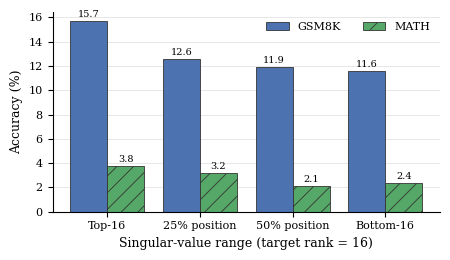

Q3 figure saved to /home/longpm/works/knowledge/big-data-nycu/hw1/outputs/2026-10-04_notebook_q1_q3/report/figures/q3_component_accuracy.png


In [21]:
import matplotlib.pyplot as plt
from cycler import cycler

ACADEMIC_PALETTE = ('#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B3', '#937860')
ACADEMIC_MARKERS = ('o', 's', '^', 'D', 'v', 'P')
ACADEMIC_HATCHES = ('', '//', '..', 'xx')
DATASET_COLOURS = {
    'GSM8K': ACADEMIC_PALETTE[0],
    'MATH': ACADEMIC_PALETTE[1],
}
BAR_EDGE_COLOUR = '#333333'
FIGURE_SIZE = (5.0, 2.6)
FIGURE_DPI = 300
FIGURE_PATH = REPORT_DIR / 'figures' / 'q3_component_accuracy'


def apply_academic_style() -> None:
    plt.rcParams.update(
        {
            'font.family': 'serif',
            'font.size': 9,
            'axes.labelsize': 9,
            'legend.fontsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'axes.spines.top': False,
            'axes.spines.right': False,
            'axes.prop_cycle': cycler(color=ACADEMIC_PALETTE, marker=ACADEMIC_MARKERS),
            'grid.color': '#DDDDDD',
            'grid.linewidth': 0.5,
            'hatch.linewidth': 0.6,
            'legend.frameon': False,
            'savefig.dpi': FIGURE_DPI,
            'savefig.bbox': 'tight',
            'pdf.fonttype': 42,
        }
    )


def plot_component_accuracy(*, table: pd.DataFrame) -> plt.Figure:
    positions = np.arange(len(table.index))
    width = 0.8 / len(table.columns)
    figure, axis = plt.subplots(figsize=FIGURE_SIZE)
    for index, dataset in enumerate(table.columns):
        offsets = positions + (index - (len(table.columns) - 1) / 2) * width
        bars = axis.bar(
            offsets,
            table[dataset].to_numpy(),
            width=width,
            label=dataset,
            color=DATASET_COLOURS[dataset],
            edgecolor=BAR_EDGE_COLOUR,
            linewidth=0.6,
            hatch=ACADEMIC_HATCHES[index % len(ACADEMIC_HATCHES)],
        )
        axis.bar_label(
            bars,
            labels=[f'{value:.1f}' for value in table[dataset]],
            padding=1.5,
            fontsize=7,
        )
    axis.set_xticks(positions)
    axis.set_xticklabels(table.index)
    axis.set_xlabel(f'Singular-value range (target rank = {COMPONENT_RANK})')
    axis.set_ylabel('Accuracy (%)')
    axis.set_ylim(bottom=0)
    axis.margins(y=0.15)
    axis.yaxis.grid(True)
    axis.set_axisbelow(True)
    axis.legend(
        loc='upper right',
        ncol=len(table.columns),
    )
    return figure


def save_figure(
    *,
    figure: plt.Figure,
    path: Path,
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    for suffix in ('.pdf', '.png'):
        figure.savefig(path.with_suffix(suffix))


if q3_component_accuracy.empty:
    raise RuntimeError('No successful rank-16 runs for the Q3 bar chart.')

apply_academic_style()
component_figure = plot_component_accuracy(table=q3_component_accuracy)
save_figure(
    figure=component_figure,
    path=FIGURE_PATH,
)
plt.show()
print('Q3 figure saved to', FIGURE_PATH.with_suffix('.png'))